
# Project P.7: Treasury Futures Options - Vol Regimes and Market Structure

This notebook follows P.7 and is structured in your usual style: imports and helper functions at the top, then Q1-Q5 with code and interpretation scaffolding.


In [1]:

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import norm
from scipy.optimize import brentq, minimize

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 160)



## Helper Functions

Core utilities for:
- loading TY option and swaption data,
- converting delta vols to strike smiles via Black inversion,
- SABR calibration with ATM pinning ($\beta=0.5$),
- plotting and summary tables.


In [2]:

DATA_DIR = 'data'
TY_FILE = f'{DATA_DIR}/ty_option_surfaces_p7.xlsx'
SWAPTION_FILE = f'{DATA_DIR}/swaption_smile_daily_2025.xlsx'

CONTRACT_SHEETS = {
    'M2025': 'CBT TY TY M2025',
    'H2026': 'CBT TY TY H2026',
    'M2026': 'CBT TY TY M2026',
}


def load_ty_contracts(path=TY_FILE):
    out = {}
    for short, sheet in CONTRACT_SHEETS.items():
        df = pd.read_excel(path, sheet_name=sheet)
        df['date'] = pd.to_datetime(df['date'])
        df = df.sort_values('date').reset_index(drop=True)
        out[short] = df
    return out


def load_swaption_data(path=SWAPTION_FILE):
    vols = pd.read_excel(path, sheet_name='black_vol_pct')
    fwd = pd.read_excel(path, sheet_name='atm_forward')
    strikes = pd.read_excel(path, sheet_name='absolute_strikes_pct')

    for d in (vols, fwd, strikes):
        d['date'] = pd.to_datetime(d['date'])

    # Convert vol to decimal.
    strike_cols = [c for c in vols.columns if c != 'date']
    vols[strike_cols] = vols[strike_cols] / 100.0

    merged = vols.merge(fwd, on='date', how='inner').merge(strikes, on='date', how='inner', suffixes=('_vol', '_K'))
    return merged, strike_cols


def nearest_date(df, target_date):
    target_date = pd.Timestamp(target_date)
    i = np.argmin(np.abs(df['date'].values - target_date.to_datetime64()))
    return pd.Timestamp(df.loc[i, 'date'])


def parse_delta_col(col_name):
    # e.g. P25dvol -> ('P', 0.25)
    cp = col_name[0]
    d = float(col_name[1:-4]) / 100.0
    return cp, d


def delta_to_strike(F, sigma, T, delta_abs, cp):
    # Black futures delta inversion.
    # Put delta magnitude convention: |Delta_put| = N(-d1)
    sigma = max(float(sigma), 1e-8)
    T = max(float(T), 1e-8)
    delta_abs = float(np.clip(delta_abs, 1e-6, 1 - 1e-6))

    if cp.upper() == 'P':
        q = norm.ppf(delta_abs)
        K = F * np.exp(q * sigma * np.sqrt(T) + 0.5 * sigma * sigma * T)
    else:
        q = norm.ppf(delta_abs)
        K = F * np.exp(-q * sigma * np.sqrt(T) + 0.5 * sigma * sigma * T)
    return float(K)


def build_ty_smile_from_row(row):
    F = float(row['Future Price'])
    T = float(row['Expiration Option'])
    recs = []

    vol_cols = [c for c in row.index if (isinstance(c, str) and c.endswith('dvol') and c[0] in ('P', 'C'))]
    for col in vol_cols:
        vol = row[col]
        if pd.isna(vol):
            continue
        cp, d_abs = parse_delta_col(col)
        K = delta_to_strike(F, vol, T, d_abs, cp)
        delta_signed = d_abs if cp == 'C' else -d_abs
        recs.append({'cp': cp, 'delta': delta_signed, 'K': K, 'iv': float(vol), 'label': col})

    smile = pd.DataFrame(recs).sort_values('K').reset_index(drop=True)
    return smile


def _sabr_atm(F, T, alpha, beta, rho, nu):
    B = (
        (1 - beta) ** 2 * alpha ** 2 / (24 * F ** (2 - 2 * beta))
        + rho * beta * nu * alpha / (4 * F ** (1 - beta))
        + (2 - 3 * rho ** 2) * nu ** 2 / 24
    )
    return alpha / F ** (1 - beta) * (1 + B * T)


def sabr_vol(F, K, T, alpha, beta, rho, nu):
    K = np.atleast_1d(np.asarray(K, dtype=float))
    out = np.zeros(K.shape, dtype=float)

    for i, Ki in enumerate(K.flat):
        if abs(Ki - F) < max(1e-9, F * 1e-9):
            out.flat[i] = _sabr_atm(F, T, alpha, beta, rho, nu)
            continue

        FK = (F * Ki) ** ((1 - beta) / 2)
        lg = np.log(F / Ki)
        z = (nu / alpha) * FK * lg
        inner = np.sqrt(1 - 2 * rho * z + z * z) + z - rho
        if inner <= 1e-14:
            out.flat[i] = np.nan
            continue

        chi = np.log(inner / (1 - rho))
        zchi = z / chi if abs(chi) > 1e-12 else 1.0

        denom = FK * (1 + (1 - beta) ** 2 / 24 * lg ** 2 + (1 - beta) ** 4 / 1920 * lg ** 4)
        B = (
            (1 - beta) ** 2 * alpha ** 2 / (24 * (F * Ki) ** (1 - beta))
            + rho * beta * nu * alpha / (4 * FK)
            + (2 - 3 * rho ** 2) * nu ** 2 / 24
        )
        out.flat[i] = alpha / denom * zchi * (1 + B * T)

    return float(out[0]) if out.size == 1 else out


def solve_alpha_from_atm(F, T, beta, rho, nu, sigma_atm):
    def f(a):
        return _sabr_atm(F, T, a, beta, rho, nu) - sigma_atm

    lo, hi = 1e-8, 2.0
    flo, fhi = f(lo), f(hi)
    guard = 0
    while flo * fhi > 0 and guard < 20:
        hi *= 2.0
        fhi = f(hi)
        guard += 1

    if flo * fhi > 0:
        return np.nan

    try:
        return brentq(f, lo, hi, xtol=1e-12, rtol=1e-10, maxiter=200)
    except Exception:
        return np.nan


def calibrate_sabr_atm_pinned(F, T, K, sigma_mkt, beta=0.5, init=None):
    K = np.asarray(K, dtype=float)
    sigma_mkt = np.asarray(sigma_mkt, dtype=float)

    m = np.isfinite(K) & np.isfinite(sigma_mkt) & (K > 0) & (sigma_mkt > 0)
    K = K[m]
    sigma_mkt = sigma_mkt[m]

    if len(K) < 5:
        return {'alpha': np.nan, 'rho': np.nan, 'nu': np.nan, 'rmse': np.nan, 'sse': np.nan, 'n': len(K)}

    # Use average of nearest-to-ATM points for ATM vol pin.
    atm_idx = np.argsort(np.abs(K - F))[:2]
    sigma_atm = float(np.mean(sigma_mkt[atm_idx]))

    def objective(x):
        rho, nu = x
        if abs(rho) >= 0.999 or nu <= 1e-6:
            return 1e10
        alpha = solve_alpha_from_atm(F, T, beta, rho, nu, sigma_atm)
        if not np.isfinite(alpha) or alpha <= 0:
            return 1e10
        fit = sabr_vol(F, K, T, alpha, beta, rho, nu)
        if np.any(~np.isfinite(fit)):
            return 1e10
        err = fit - sigma_mkt
        return float(np.sum(err ** 2))

    starts = []
    if init is not None and np.all(np.isfinite(init)):
        starts.append(np.array(init, dtype=float))
    starts += [
        np.array([0.0, 0.35]),
        np.array([-0.2, 0.6]),
        np.array([0.2, 0.5]),
        np.array([-0.4, 1.0]),
    ]

    best = None
    for x0 in starts:
        try:
            res = minimize(
                objective,
                x0=x0,
                method='L-BFGS-B',
                bounds=[(-0.999, 0.999), (1e-4, 5.0)],
                options={'maxiter': 600},
            )
            if best is None or res.fun < best.fun:
                best = res
        except Exception:
            pass

    if best is None:
        return {'alpha': np.nan, 'rho': np.nan, 'nu': np.nan, 'rmse': np.nan, 'sse': np.nan, 'n': len(K)}

    rho, nu = best.x
    alpha = solve_alpha_from_atm(F, T, beta, rho, nu, sigma_atm)
    fit = sabr_vol(F, K, T, alpha, beta, rho, nu)
    rmse = float(np.sqrt(np.mean((fit - sigma_mkt) ** 2)))

    return {
        'alpha': float(alpha),
        'rho': float(rho),
        'nu': float(nu),
        'rmse': rmse,
        'sse': float(np.sum((fit - sigma_mkt) ** 2)),
        'n': int(len(K)),
        'sigma_atm': sigma_atm,
        'fit': fit,
        'K': K,
        'sigma_mkt': sigma_mkt,
    }


def calibrate_contract_daily(df_contract, contract_name, beta=0.5, step=1):
    rows = []
    prev_init = None
    for i in range(0, len(df_contract), step):
        row = df_contract.iloc[i]
        smile = build_ty_smile_from_row(row)
        res = calibrate_sabr_atm_pinned(
            F=float(row['Future Price']),
            T=float(row['Expiration Option']),
            K=smile['K'].values,
            sigma_mkt=smile['iv'].values,
            beta=beta,
            init=prev_init,
        )

        if np.isfinite(res.get('rho', np.nan)) and np.isfinite(res.get('nu', np.nan)):
            prev_init = [res['rho'], res['nu']]

        rows.append({
            'contract': contract_name,
            'date': pd.Timestamp(row['date']),
            'F': float(row['Future Price']),
            'T': float(row['Expiration Option']),
            'atm_vol': float((row.get('P50dvol', np.nan) + row.get('C50dvol', np.nan)) / 2),
            'alpha': res['alpha'],
            'rho': res['rho'],
            'nu': res['nu'],
            'rmse': res['rmse'],
            'n_points': res['n'],
        })

    out = pd.DataFrame(rows).sort_values('date').reset_index(drop=True)
    return out


def black_delta_futures(F, K, sigma, T, cp='C'):
    if T <= 0 or sigma <= 0:
        if cp == 'C':
            return 1.0 if F > K else 0.0
        return -1.0 if F < K else 0.0
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / (sigma * np.sqrt(T))
    if cp == 'C':
        return float(norm.cdf(d1))
    return float(norm.cdf(d1) - 1.0)


def black_vega_futures(F, K, sigma, T):
    if T <= 0 or sigma <= 0:
        return 0.0
    d1 = (np.log(F / K) + 0.5 * sigma * sigma * T) / (sigma * np.sqrt(T))
    return float(F * norm.pdf(d1) * np.sqrt(T))



## Load Data


In [3]:

ty_contracts = load_ty_contracts(TY_FILE)
swaption_merged, swaption_offsets = load_swaption_data(SWAPTION_FILE)

for k, v in ty_contracts.items():
    print(k, v['date'].min().date(), '->', v['date'].max().date(), '| rows =', len(v))
print('Swaption rows:', len(swaption_merged))


M2025 2025-03-03 -> 2025-05-22 | rows = 59
H2026 2025-11-03 -> 2026-02-19 | rows = 78
M2026 2026-01-02 -> 2026-02-27 | rows = 41
Swaption rows: 21



## Question 1: Implied Vol Surface Construction

The provided data gives implied volatilities by delta (e.g., 25-delta put, 50-delta put). Convert these to strike-based smiles.

a) For a representative date early in the M2025 sample, invert the Black delta formula to recover the strike corresponding to each delta point. Display the smile as implied vol vs. strike.

b) As a concrete starting point using an event from C.8.1, plot the smile for three dates around the April 2025 tariff episode (one day before, shock day, pause day). Comment on how the shape changes, not just the level.

c) Compare the TY option smile to the 1Yx5Y swaption smile from C.8.1 on the same date. Choose a normalization that makes the comparison meaningful given different ATM levels. Are there visible differences in skew or curvature?

Delta-to-strike inversion used:
- Put: $K = F \exp\!\left(\Phi^{-1}(\Delta_{\text{put,abs}})\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\right)$
- Call: $K = F \exp\!\left(-\Phi^{-1}(\Delta_{\text{call}})\,\sigma\sqrt{T} + \tfrac{1}{2}\sigma^2 T\right)$


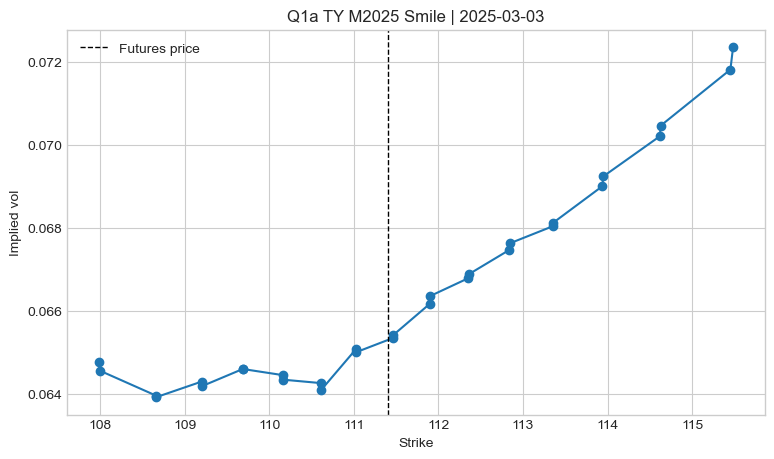

,cp,delta,K,iv,label
0,C,0.85,107.984217,0.064771,C85dvol
1,P,-0.15,107.995080,0.064559,P15dvol
2,P,-0.20,108.662769,0.063955,P20dvol
3,C,0.80,108.664100,0.063923,C80dvol
4,P,-0.25,109.200633,0.064298,P25dvol
5,C,0.75,109.204283,0.064188,C75dvol
6,C,0.70,109.691004,0.064605,C70dvol
7,P,-0.30,109.691182,0.064598,P30dvol
8,C,0.65,110.159712,0.064452,C65dvol
9,P,-0.35,110.161723,0.064343,P35dvol


In [4]:

# Q1a: representative early date in M2025
m2025 = ty_contracts['M2025'].copy()
rep_date = m2025['date'].min()
rep_row = m2025.loc[m2025['date'] == rep_date].iloc[0]
rep_smile = build_ty_smile_from_row(rep_row)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rep_smile['K'], rep_smile['iv'], 'o-', lw=1.5)
ax.axvline(rep_row['Future Price'], color='k', ls='--', lw=1, label='Futures price')
ax.set_title(f'Q1a TY M2025 Smile | {rep_date.date()}')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied vol')
ax.legend()
plt.show()

rep_smile.head(10)


Selected event dates:
  Pre day (target 2025-04-02): 2025-04-02
  Shock day (target 2025-04-03): 2025-04-03
  Pause day (target 2025-04-09): 2025-04-09


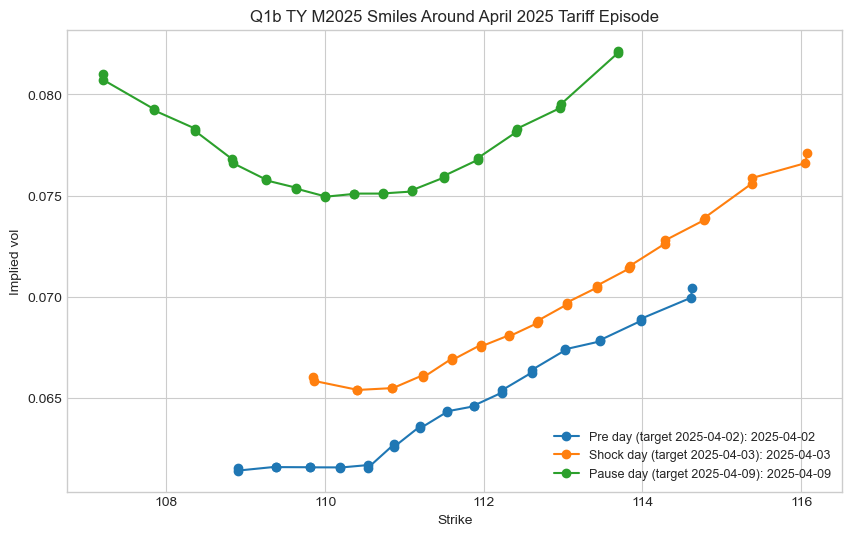

In [5]:

# Q1b: three tariff-episode dates (adjustable)
# Assumption from the April-2025 episode timeline:
# pre = 2025-04-02, shock = 2025-04-03, pause = 2025-04-09
event_targets = {
    'Pre day (target 2025-04-02)': '2025-04-02',
    'Shock day (target 2025-04-03)': '2025-04-03',
    'Pause day (target 2025-04-09)': '2025-04-09',
}

event_dates = {k: nearest_date(m2025, v) for k, v in event_targets.items()}
print('Selected event dates:')
for k, d in event_dates.items():
    print(f'  {k}: {d.date()}')

fig, ax = plt.subplots(figsize=(10, 6))
for label, d in event_dates.items():
    row = m2025.loc[m2025['date'] == d].iloc[0]
    smile = build_ty_smile_from_row(row)
    ax.plot(smile['K'], smile['iv'], marker='o', lw=1.5, label=f"{label}: {d.date()}")

ax.set_title('Q1b TY M2025 Smiles Around April 2025 Tariff Episode')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied vol')
ax.legend(fontsize=9)
plt.show()


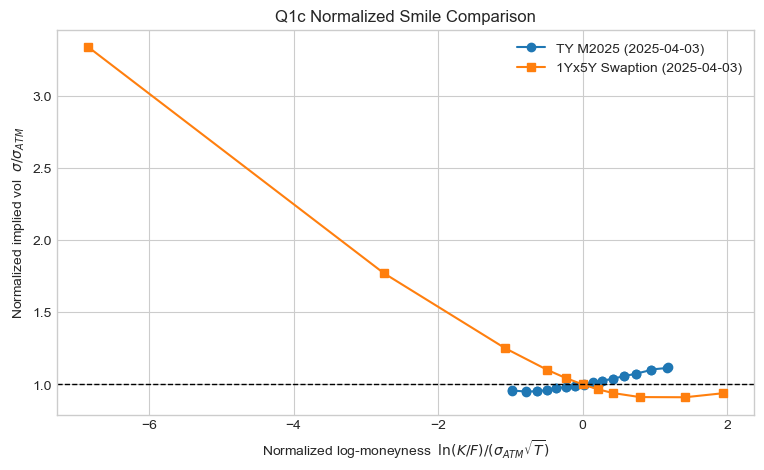

,metric,value
0,compare_date,2025-04-03
1,TY_atm_vol,0.068762
2,Swaption_atm_vol,0.3304


In [6]:

# Q1c: TY vs 1Yx5Y swaption normalized smile on the same date
cmp_date = nearest_date(m2025, '2025-04-03')
row_ty = m2025.loc[m2025['date'] == cmp_date].iloc[0]
smile_ty = build_ty_smile_from_row(row_ty)

swp_row = swaption_merged.loc[swaption_merged['date'] == cmp_date]
if swp_row.empty:
    cmp_date = swaption_merged['date'].iloc[np.argmin(np.abs(swaption_merged['date'].values - cmp_date.to_datetime64()))]
    row_ty = m2025.loc[m2025['date'] == nearest_date(m2025, cmp_date)].iloc[0]
    smile_ty = build_ty_smile_from_row(row_ty)
    swp_row = swaption_merged.loc[swaption_merged['date'] == cmp_date]
swp_row = swp_row.iloc[0]

# Normalization: x-axis = log-moneyness scaled by ATM std dev, y-axis = vol / ATM vol.
F_ty = float(row_ty['Future Price'])
T_ty = float(row_ty['Expiration Option'])
atm_ty = float((row_ty['P50dvol'] + row_ty['C50dvol']) / 2)

x_ty = np.log(smile_ty['K'].values / F_ty) / (atm_ty * np.sqrt(T_ty))
y_ty = smile_ty['iv'].values / atm_ty

# Swaption assumptions: option expiry is 1Y for 1Yx5Y.
F_sw = float(swp_row['atm_fwd_pct'])
K_sw = np.array([float(swp_row[f'{c}_K']) for c in swaption_offsets])
vol_sw = np.array([float(swp_row[f'{c}_vol']) for c in swaption_offsets])
T_sw = 1.0
atm_sw = float(swp_row['0_vol'])

x_sw = np.log(K_sw / F_sw) / (atm_sw * np.sqrt(T_sw))
y_sw = vol_sw / atm_sw

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_ty, y_ty, 'o-', label=f'TY M2025 ({row_ty["date"].date()})')
ax.plot(x_sw, y_sw, 's-', label=f'1Yx5Y Swaption ({cmp_date.date()})')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_title('Q1c Normalized Smile Comparison')
ax.set_xlabel('Normalized log-moneyness  $\ln(K/F)/(\sigma_{ATM}\sqrt{T})$')
ax.set_ylabel('Normalized implied vol  $\sigma/\sigma_{ATM}$')
ax.legend()
plt.show()

pd.DataFrame({
    'metric': ['compare_date', 'TY_atm_vol', 'Swaption_atm_vol'],
    'value': [str(cmp_date.date()), atm_ty, atm_sw],
})



## Question 2: SABR Calibration

Calibrate SABR with $\beta = 0.5$ to the TY futures option smile.

a) For the representative date from Q1a, minimize the sum of squared vol errors over $(\nu,\rho)$, solving for $\alpha$ from the ATM constraint each step. Report fitted parameters and overlay fitted vs market smile.

b) Repeat for each trading day (daily here) across M2025, H2026, M2026. Report $(\alpha,\nu,\rho)$ time series and summary statistics by contract.

c) Report daily RMSE of calibrations. Identify dates/contracts with notably worse fit.


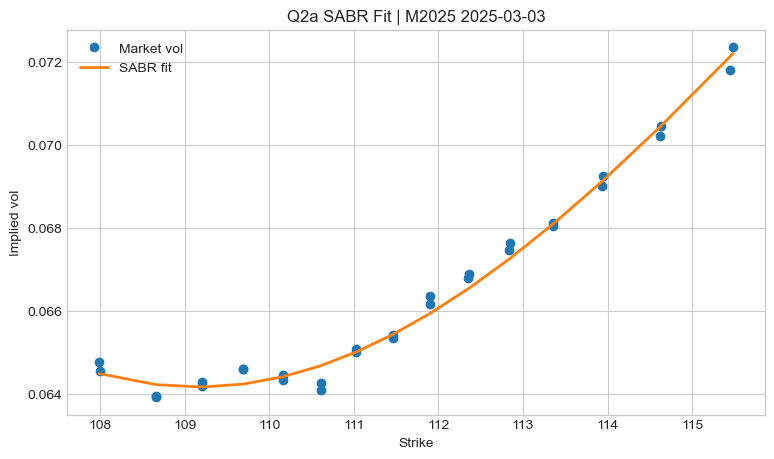

,parameter,value
0,alpha,0.677420
1,rho,0.250226
2,nu,1.039737
3,rmse,0.000250


In [7]:

# Q2a: representative-date calibration and overlay
beta = 0.5
res_rep = calibrate_sabr_atm_pinned(
    F=float(rep_row['Future Price']),
    T=float(rep_row['Expiration Option']),
    K=rep_smile['K'].values,
    sigma_mkt=rep_smile['iv'].values,
    beta=beta,
)

fit_rep = sabr_vol(
    float(rep_row['Future Price']),
    rep_smile['K'].values,
    float(rep_row['Expiration Option']),
    res_rep['alpha'], beta, res_rep['rho'], res_rep['nu']
)

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(rep_smile['K'], rep_smile['iv'], 'o', label='Market vol')
ax.plot(rep_smile['K'], fit_rep, '-', lw=2, label='SABR fit')
ax.set_title(f'Q2a SABR Fit | M2025 {rep_date.date()}')
ax.set_xlabel('Strike')
ax.set_ylabel('Implied vol')
ax.legend()
plt.show()

pd.DataFrame({
    'parameter': ['alpha', 'rho', 'nu', 'rmse'],
    'value': [res_rep['alpha'], res_rep['rho'], res_rep['nu'], res_rep['rmse']]
})


In [8]:

# Q2b/Q2c: daily calibration across all TY contracts
calib_frames = []
for c, df in ty_contracts.items():
    print(f'Calibrating {c}...')
    out = calibrate_contract_daily(df, contract_name=c, beta=0.5, step=1)
    calib_frames.append(out)

calib_all = pd.concat(calib_frames, ignore_index=True).sort_values(['contract', 'date']).reset_index(drop=True)

summary_q2 = calib_all.groupby('contract')[['alpha', 'rho', 'nu', 'rmse']].agg(['mean', 'std', 'min', 'max'])
summary_q2


Calibrating M2025...


Calibrating H2026...


Calibrating M2026...


alpha                                     rho                                      nu                                    rmse            \
              mean       std       min       max      mean       std       min       max      mean       std       min       max      mean       std   
contract                                                                                                                                               
H2026     0.459492  0.054671  0.352026  0.548204  0.165375  0.192351 -0.135349  0.983438  1.981201  1.141970  0.784240  5.000000  0.000612  0.000918   
M2025     0.698506  0.067685  0.565536  0.848844  0.115018  0.340600 -0.999000  0.809587  1.663517  0.931832  0.346337  5.000000  0.000803  0.000866   
M2026     0.454905  0.014840  0.432155  0.486208  0.142613  0.111934 -0.028945  0.404945  1.358349  0.184456  1.005327  1.696464  0.000257  0.000055   

                              
               min       max  
contract                      
H2026     0.000113  0.005694  
M2025     0.000216  0.003767  
M2026     0.000174  0.000420

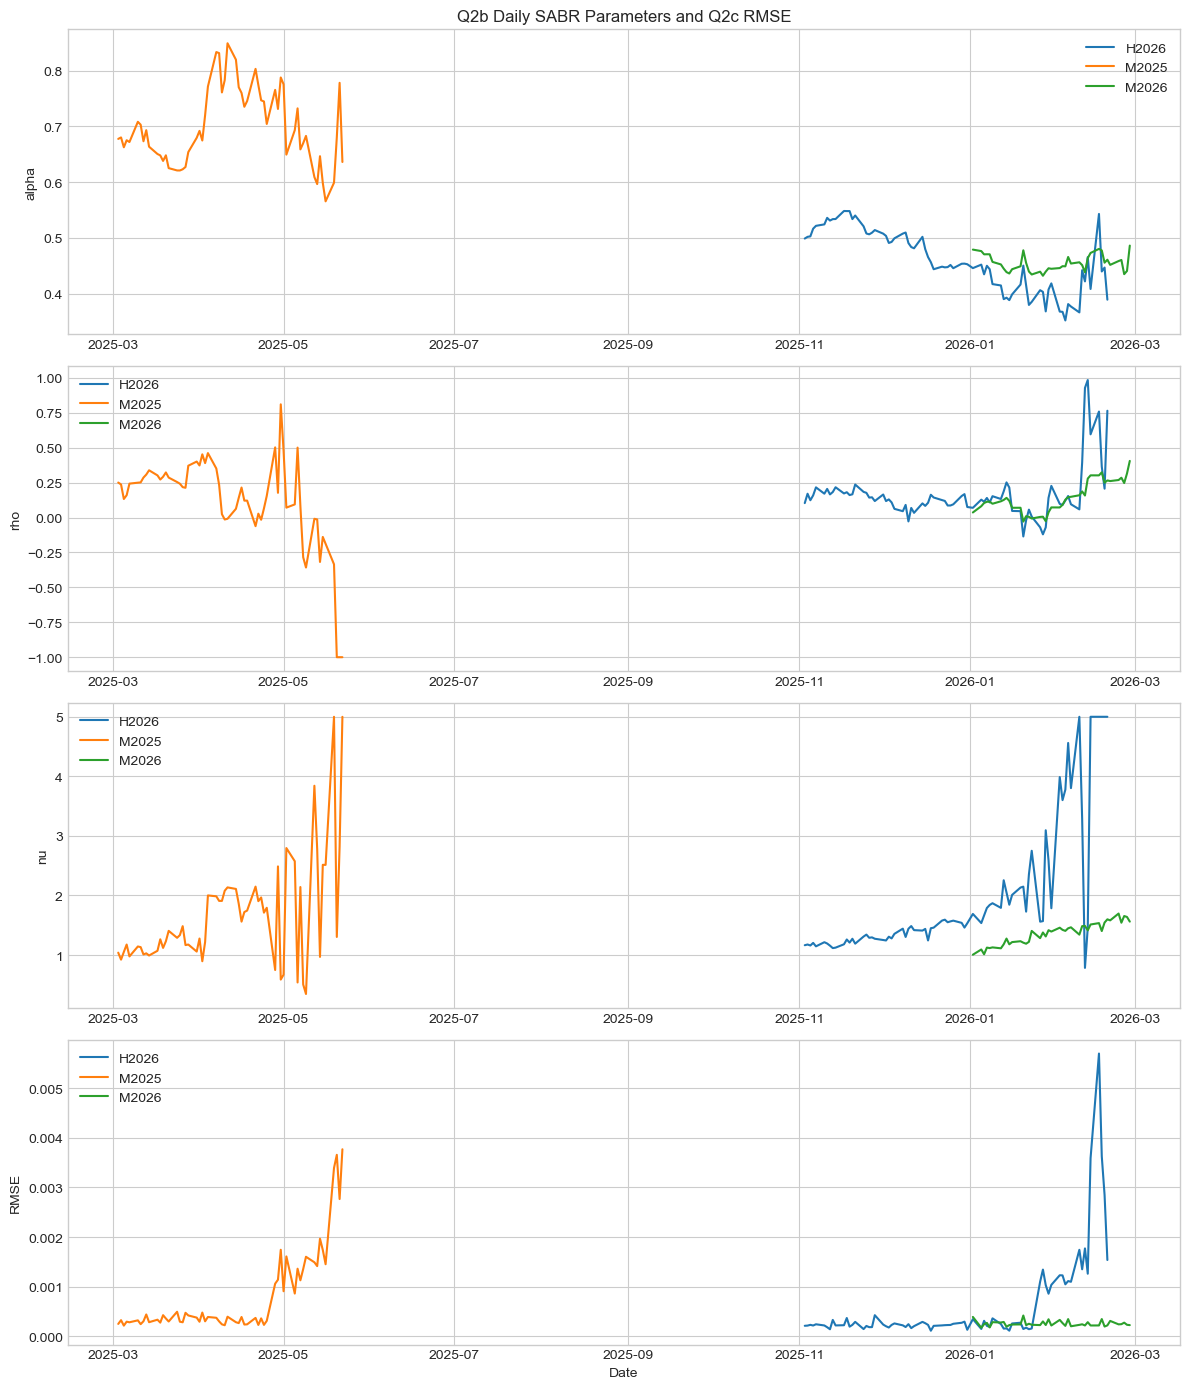

,contract,date,rmse,atm_vol,alpha,rho,nu
74,H2026,2026-02-16,0.005694,0.051219,0.542928,0.758102,5.000000
136,M2025,2025-05-22,0.003767,0.060477,0.636055,-0.999000,4.999556
134,M2025,2025-05-20,0.003655,0.064757,0.680293,-0.999000,1.303704
75,H2026,2026-02-17,0.003625,0.041963,0.439827,0.364050,5.000000
73,H2026,2026-02-13,0.003588,0.039146,0.408448,0.595059,5.000000
133,M2025,2025-05-19,0.003390,0.058199,0.598888,-0.334539,5.000000
76,H2026,2026-02-18,0.002846,0.042540,0.446817,0.206435,5.000000
135,M2025,2025-05-21,0.002765,0.074184,0.777952,-0.998990,2.820005
130,M2025,2025-05-14,0.001967,0.061812,0.646411,-0.317633,0.968749
71,H2026,2026-02-11,0.001770,0.039814,0.421994,0.926999,0.784240


In [9]:

# Parameter and RMSE time series by contract
fig, axes = plt.subplots(4, 1, figsize=(12, 14), sharex=False)
for c, d in calib_all.groupby('contract'):
    axes[0].plot(d['date'], d['alpha'], label=c)
    axes[1].plot(d['date'], d['rho'], label=c)
    axes[2].plot(d['date'], d['nu'], label=c)
    axes[3].plot(d['date'], d['rmse'], label=c)

axes[0].set_title('Q2b Daily SABR Parameters and Q2c RMSE')
axes[0].set_ylabel('alpha')
axes[1].set_ylabel('rho')
axes[2].set_ylabel('nu')
axes[3].set_ylabel('RMSE')
axes[3].set_xlabel('Date')
for ax in axes:
    ax.legend()
plt.tight_layout()
plt.show()

worst_fit_days = calib_all.sort_values('rmse', ascending=False).head(10)
worst_fit_days[['contract', 'date', 'rmse', 'atm_vol', 'alpha', 'rho', 'nu']]



## Question 3: Calibration Quality and Regime Identification

Using daily SABR calibrations:

a) Plot daily fit RMSE with ATM vol. Test whether calibration quality co-moves with volatility.

b) Rank dates by day-over-day parameter change magnitude (e.g., $|\Delta\nu| + |\Delta\rho|$). Report top 5 and show pre/post smiles for 2-3 largest events.

c) In Jan-Feb 2026 overlap window, compare H2026 vs M2026 parameters on same dates.

d) Lazy recalibration: hold $(\nu,\rho)$ from $N$ days ago ($N=5,10,20$), update only $\alpha$ from ATM each day, and compare RMSE vs full daily recalibration.


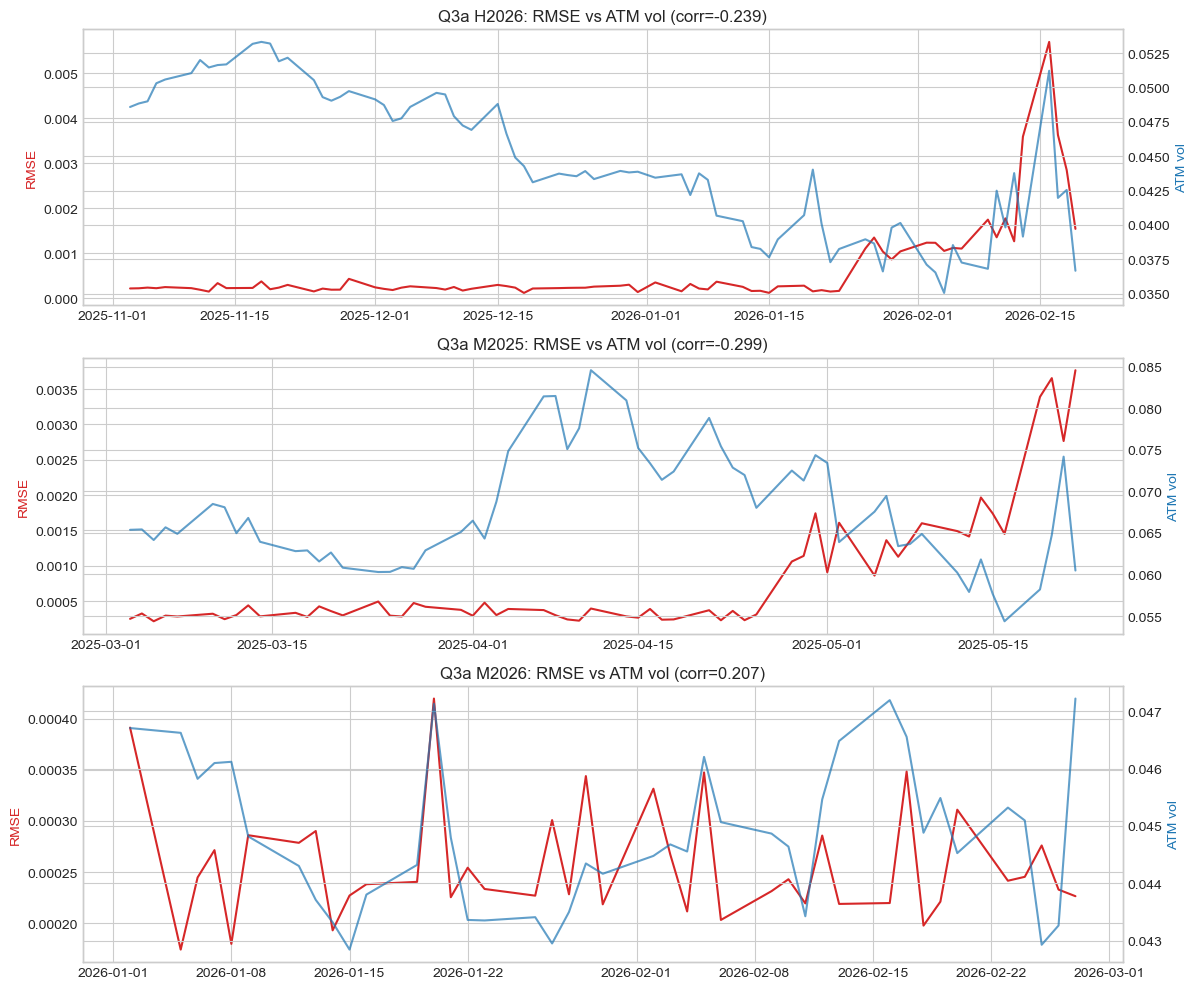

contract
H2026   -0.238839
M2025   -0.298588
M2026    0.207323
Name: corr_rmse_atmvol, dtype: float64

In [10]:

# Q3a: RMSE vs ATM vol relationship
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=False)
for i, (c, d) in enumerate(calib_all.groupby('contract')):
    ax = axes[i]
    ax2 = ax.twinx()
    ax.plot(d['date'], d['rmse'], color='tab:red', label='RMSE')
    ax2.plot(d['date'], d['atm_vol'], color='tab:blue', alpha=0.7, label='ATM vol')
    corr = d[['rmse', 'atm_vol']].corr().iloc[0, 1]
    ax.set_title(f'Q3a {c}: RMSE vs ATM vol (corr={corr:.3f})')
    ax.set_ylabel('RMSE', color='tab:red')
    ax2.set_ylabel('ATM vol', color='tab:blue')

plt.tight_layout()
plt.show()

calib_all.groupby('contract').apply(lambda x: x[['rmse', 'atm_vol']].corr().iloc[0,1]).rename('corr_rmse_atmvol')


In [11]:

# Q3b: rank parameter-change dates
chg = calib_all.copy().sort_values(['contract', 'date'])
chg['d_nu'] = chg.groupby('contract')['nu'].diff()
chg['d_rho'] = chg.groupby('contract')['rho'].diff()
chg['jump_metric'] = chg['d_nu'].abs() + chg['d_rho'].abs()

top5_jumps = chg.sort_values('jump_metric', ascending=False).head(5)
top5_jumps[['contract', 'date', 'jump_metric', 'd_nu', 'd_rho', 'nu', 'rho', 'rmse']]


,contract,date,jump_metric,d_nu,d_rho,nu,rho,rmse
134,M2025,2025-05-20,4.360757,-3.696296,-0.664460,1.303704,-0.999000,0.003655
73,H2026,2026-02-13,3.925940,3.537561,-0.388380,5.000000,0.595059,0.003588
128,M2025,2025-05-12,3.844352,3.495754,0.348598,3.842091,-0.009006,0.001491
71,H2026,2026-02-11,3.030039,-2.497398,0.532641,0.784240,0.926999,0.001770
133,M2025,2025-05-19,2.633707,2.486716,-0.146990,5.000000,-0.334539,0.003390


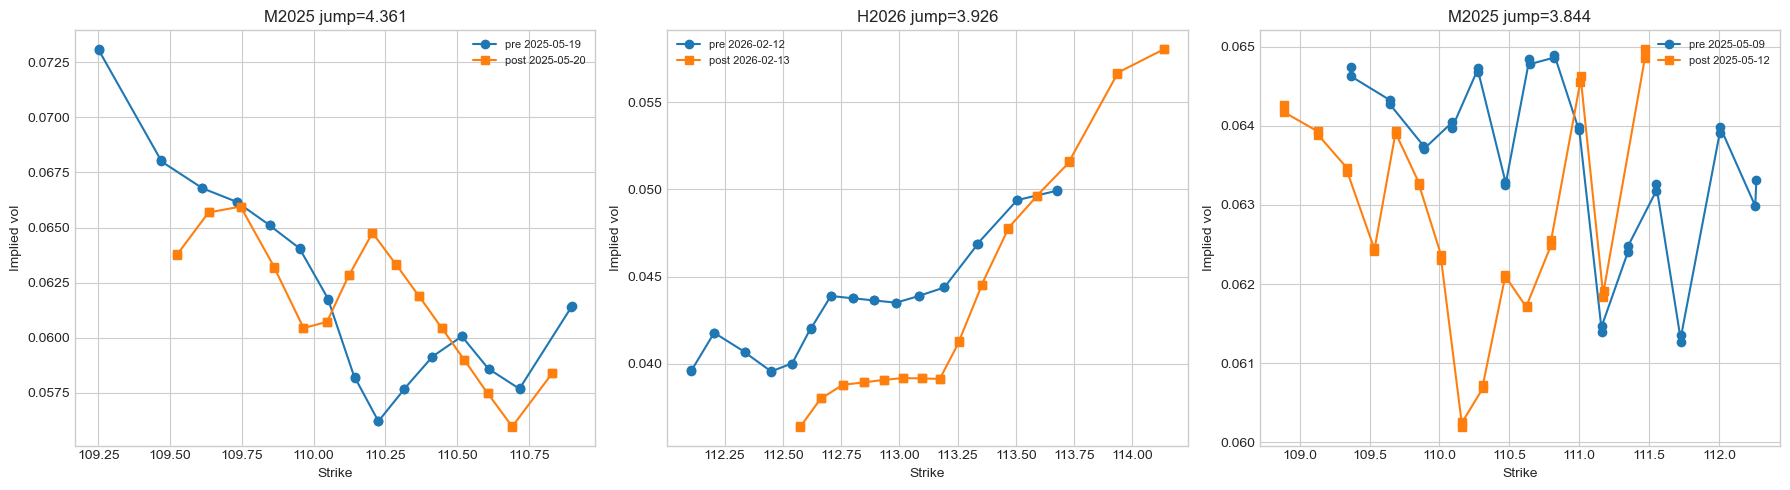

In [12]:

# Pre/post smile plots for top 3 jump dates

def get_contract_row(contract, dt):
    df = ty_contracts[contract]
    row = df.loc[df['date'] == pd.Timestamp(dt)]
    return None if row.empty else row.iloc[0]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (_, ev) in zip(axes, top5_jumps.head(3).iterrows()):
    c = ev['contract']
    d1 = pd.Timestamp(ev['date'])
    d0 = chg[(chg['contract'] == c) & (chg['date'] < d1)]['date'].max()

    r0 = get_contract_row(c, d0)
    r1 = get_contract_row(c, d1)
    s0 = build_ty_smile_from_row(r0)
    s1 = build_ty_smile_from_row(r1)

    ax.plot(s0['K'], s0['iv'], 'o-', label=f'pre {d0.date()}')
    ax.plot(s1['K'], s1['iv'], 's-', label=f'post {d1.date()}')
    ax.set_title(f'{c} jump={ev["jump_metric"]:.3f}')
    ax.set_xlabel('Strike')
    ax.set_ylabel('Implied vol')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()


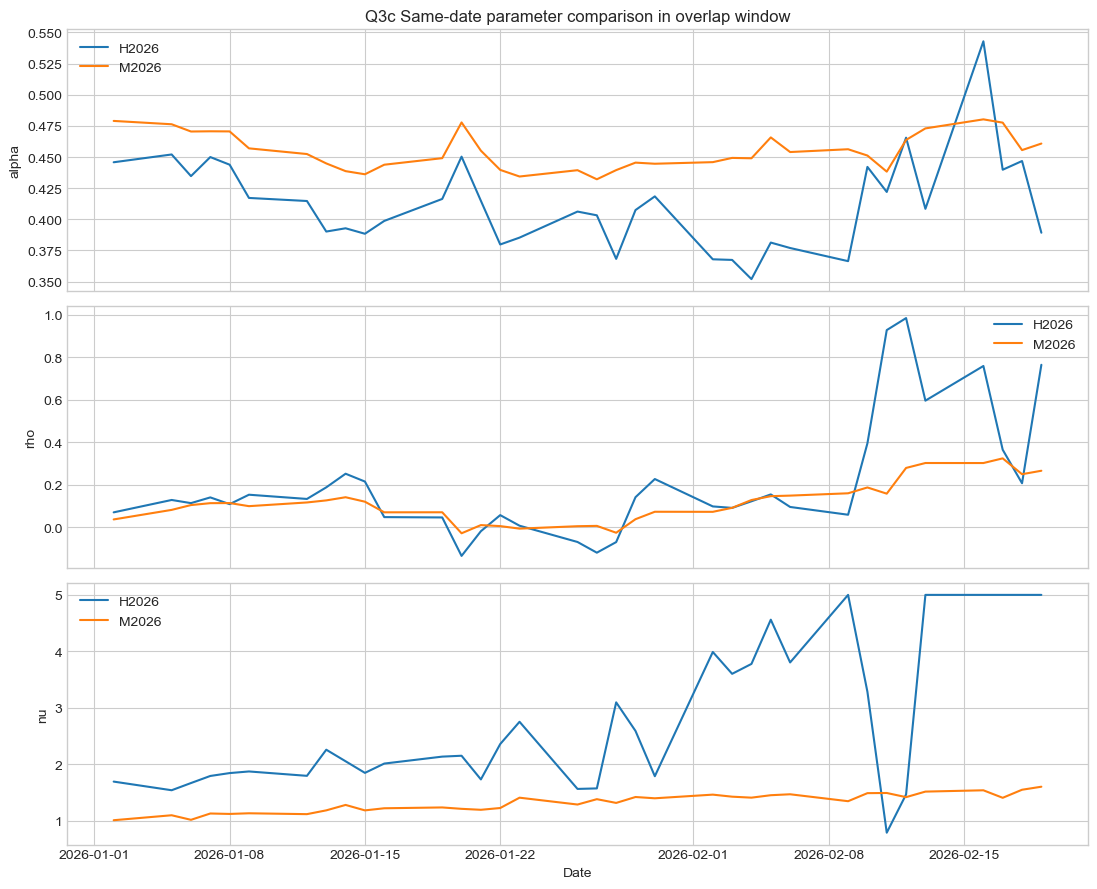

,alpha_H2026,alpha_M2026,rho_H2026,rho_M2026,nu_H2026,nu_M2026
alpha_H2026,1.000000,0.629981,0.401835,0.357664,-0.113990,-0.098599
alpha_M2026,0.629981,1.000000,0.229517,0.435101,0.267506,-0.164656
rho_H2026,0.401835,0.229517,1.000000,0.780671,0.196840,0.498048
rho_M2026,0.357664,0.435101,0.780671,1.000000,0.580418,0.501460
nu_H2026,-0.113990,0.267506,0.196840,0.580418,1.000000,0.667181
nu_M2026,-0.098599,-0.164656,0.498048,0.501460,0.667181,1.000000


In [13]:

# Q3c: H2026 vs M2026 in overlap Jan-Feb 2026
overlap_start = pd.Timestamp('2026-01-01')
overlap_end = pd.Timestamp('2026-02-28')

h = calib_all[(calib_all['contract'] == 'H2026') & (calib_all['date'].between(overlap_start, overlap_end))]
m = calib_all[(calib_all['contract'] == 'M2026') & (calib_all['date'].between(overlap_start, overlap_end))]

ov = h[['date', 'alpha', 'rho', 'nu', 'rmse']].merge(
    m[['date', 'alpha', 'rho', 'nu', 'rmse']],
    on='date',
    suffixes=('_H2026', '_M2026')
)

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
axes[0].plot(ov['date'], ov['alpha_H2026'], label='H2026')
axes[0].plot(ov['date'], ov['alpha_M2026'], label='M2026')
axes[0].set_ylabel('alpha')
axes[0].legend()

axes[1].plot(ov['date'], ov['rho_H2026'], label='H2026')
axes[1].plot(ov['date'], ov['rho_M2026'], label='M2026')
axes[1].set_ylabel('rho')
axes[1].legend()

axes[2].plot(ov['date'], ov['nu_H2026'], label='H2026')
axes[2].plot(ov['date'], ov['nu_M2026'], label='M2026')
axes[2].set_ylabel('nu')
axes[2].set_xlabel('Date')
axes[2].legend()

axes[0].set_title('Q3c Same-date parameter comparison in overlap window')
plt.tight_layout()
plt.show()

ov[[
    'alpha_H2026', 'alpha_M2026',
    'rho_H2026', 'rho_M2026',
    'nu_H2026', 'nu_M2026'
]].corr()


In [14]:

# Q3d: lazy recalibration experiment

def lazy_rmse_for_contract(contract, N_list=(5, 10, 20), beta=0.5):
    df = ty_contracts[contract].sort_values('date').reset_index(drop=True)
    full = calib_all[calib_all['contract'] == contract].sort_values('date').reset_index(drop=True)

    out_rows = []
    for N in N_list:
        rmses = []
        for i in range(N, len(df)):
            row = df.iloc[i]
            stale = full.iloc[i - N]
            if not np.isfinite(stale['rho']) or not np.isfinite(stale['nu']):
                continue

            smile = build_ty_smile_from_row(row)
            F = float(row['Future Price'])
            T = float(row['Expiration Option'])
            rho_stale = float(stale['rho'])
            nu_stale = float(stale['nu'])
            sigma_atm = float((row['P50dvol'] + row['C50dvol']) / 2)
            alpha = solve_alpha_from_atm(F, T, beta, rho_stale, nu_stale, sigma_atm)

            if not np.isfinite(alpha):
                continue

            fit = sabr_vol(F, smile['K'].values, T, alpha, beta, rho_stale, nu_stale)
            rmse = float(np.sqrt(np.mean((fit - smile['iv'].values) ** 2)))
            rmses.append(rmse)

        out_rows.append({'contract': contract, 'N': N, 'rmse_lazy_mean': np.mean(rmses), 'rmse_lazy_median': np.median(rmses)})

    base = full['rmse'].mean()
    out = pd.DataFrame(out_rows)
    out['rmse_full_mean'] = base
    out['degradation_pct'] = 100 * (out['rmse_lazy_mean'] / out['rmse_full_mean'] - 1)
    return out

lazy_tables = [lazy_rmse_for_contract(c) for c in CONTRACT_SHEETS.keys()]
lazy_summary = pd.concat(lazy_tables, ignore_index=True)
lazy_summary


,contract,N,rmse_lazy_mean,rmse_lazy_median,rmse_full_mean,degradation_pct
0,M2025,5,0.002252,0.001795,0.000803,180.612798
1,M2025,10,0.002435,0.002018,0.000803,203.400336
2,M2025,20,0.002777,0.002280,0.000803,246.026965
3,H2026,5,0.001216,0.000680,0.000612,98.832903
4,H2026,10,0.001402,0.000776,0.000612,129.157729
5,H2026,20,0.001649,0.001083,0.000612,169.550597
6,M2026,5,0.000891,0.000823,0.000257,246.312681
7,M2026,10,0.001423,0.001352,0.000257,453.235071
8,M2026,20,0.002195,0.002792,0.000257,753.588263



## Question 4: Listed vs OTC - Cross-Product Comparison

Using the April 2025 overlap between TY options and 1Yx5Y swaptions:

a) Calibrate SABR ($\beta=0.5$) to swaption smiles daily in April and plot $(\alpha,\nu,\rho)$ for both products.

b) On TY's largest day-over-day jump dates (Q3b), compare swaption parameter changes and whether $\nu,\rho$ move in the same direction/magnitude.

c) Normalize each product smile by ATM vol and overlay.

d) Add interpretation of why differences may exist.


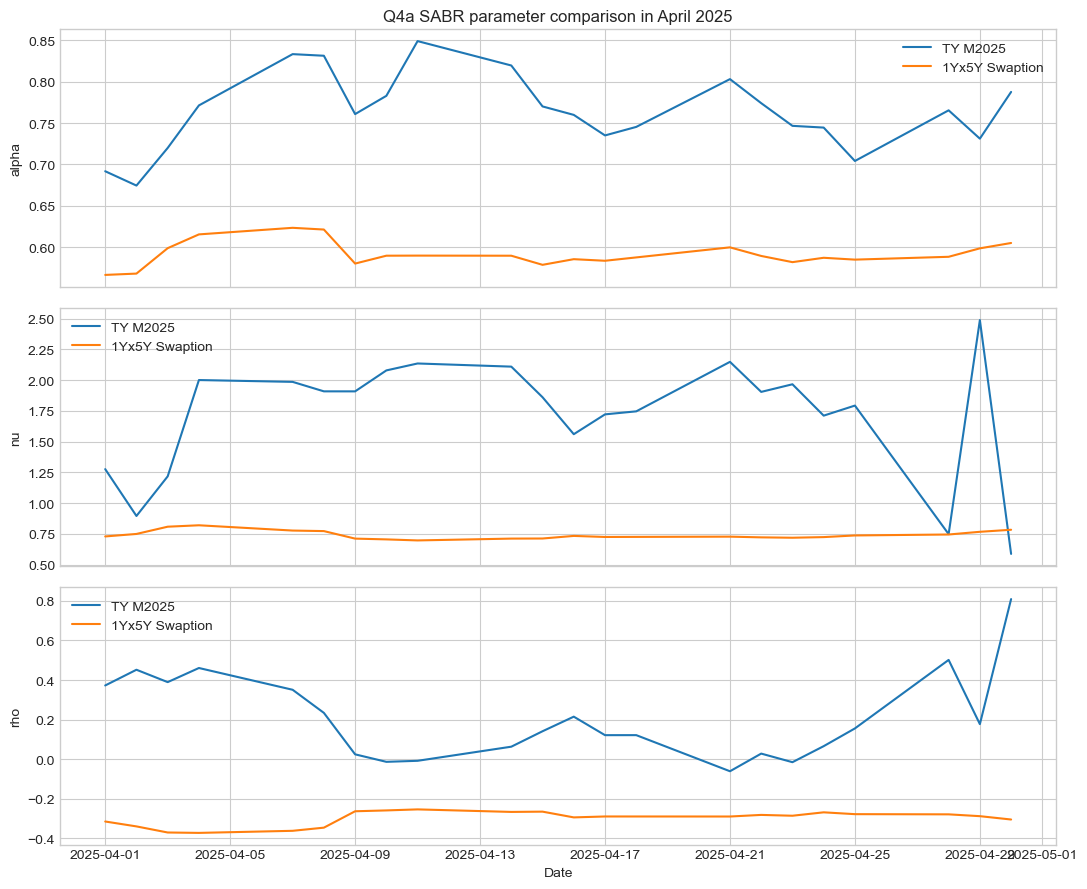

In [15]:

# Q4a: Swaption daily SABR calibration in April 2025
swp = swaption_merged.copy()
swp_apr = swp[swp['date'].between('2025-04-01', '2025-04-30')].sort_values('date').reset_index(drop=True)

swp_rows = []
prev = None
for _, r in swp_apr.iterrows():
    F = float(r['atm_fwd_pct'])  # in percent points
    K = np.array([float(r[f'{c}_K']) for c in swaption_offsets])
    vol = np.array([float(r[f'{c}_vol']) for c in swaption_offsets])

    res = calibrate_sabr_atm_pinned(F=F, T=1.0, K=K, sigma_mkt=vol, beta=0.5, init=prev)
    if np.isfinite(res['rho']) and np.isfinite(res['nu']):
        prev = [res['rho'], res['nu']]

    swp_rows.append({
        'date': r['date'],
        'alpha': res['alpha'],
        'rho': res['rho'],
        'nu': res['nu'],
        'rmse': res['rmse'],
    })

swp_calib = pd.DataFrame(swp_rows)

# TY April sample (use M2025)
ty_apr = calib_all[(calib_all['contract'] == 'M2025') & (calib_all['date'].between('2025-04-01', '2025-04-30'))].copy()

fig, axes = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
for ax, p in zip(axes, ['alpha', 'nu', 'rho']):
    ax.plot(ty_apr['date'], ty_apr[p], label='TY M2025')
    ax.plot(swp_calib['date'], swp_calib[p], label='1Yx5Y Swaption')
    ax.set_ylabel(p)
    ax.legend()
axes[0].set_title('Q4a SABR parameter comparison in April 2025')
axes[-1].set_xlabel('Date')
plt.tight_layout()
plt.show()


In [16]:

# Q4b: compare parameter changes on TY jump dates
swp_cmp = swp_calib.sort_values('date').copy()
swp_cmp['d_nu'] = swp_cmp['nu'].diff()
swp_cmp['d_rho'] = swp_cmp['rho'].diff()

ty_jumps = top5_jumps[['contract', 'date', 'd_nu', 'd_rho', 'jump_metric']].copy()
ty_jumps = ty_jumps[ty_jumps['date'].between('2025-04-01', '2025-04-30')]

rows = []
for _, r in ty_jumps.iterrows():
    d = pd.Timestamp(r['date'])
    srow = swp_cmp[swp_cmp['date'] == d]
    if srow.empty:
        continue
    srow = srow.iloc[0]
    rows.append({
        'date': d,
        'TY_d_nu': r['d_nu'],
        'TY_d_rho': r['d_rho'],
        'SWP_d_nu': srow['d_nu'],
        'SWP_d_rho': srow['d_rho'],
        'same_sign_nu': np.sign(r['d_nu']) == np.sign(srow['d_nu']),
        'same_sign_rho': np.sign(r['d_rho']) == np.sign(srow['d_rho']),
    })

q4b_table = pd.DataFrame(rows)
q4b_table


""


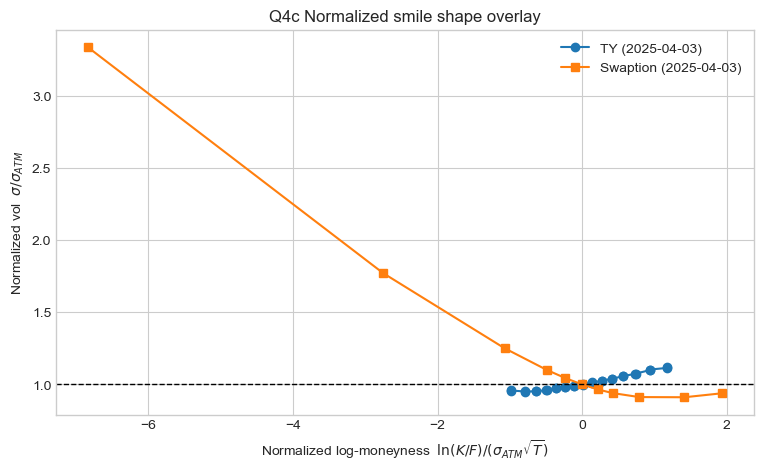

Overlay TY date: 2025-04-03 | Overlay swaption date: 2025-04-03


In [17]:

# Q4c: normalized smile overlay on a key April date
if not q4b_table.empty:
    overlay_date = q4b_table['date'].iloc[0]
else:
    overlay_date = pd.Timestamp('2025-04-03')

# TY side
d_ty = nearest_date(ty_contracts['M2025'], overlay_date)
r_ty = ty_contracts['M2025'].loc[ty_contracts['M2025']['date'] == d_ty].iloc[0]
s_ty = build_ty_smile_from_row(r_ty)
F_ty = float(r_ty['Future Price'])
T_ty = float(r_ty['Expiration Option'])
atm_ty = float((r_ty['P50dvol'] + r_ty['C50dvol']) / 2)

x_ty = np.log(s_ty['K'].values / F_ty) / (atm_ty * np.sqrt(T_ty))
y_ty = s_ty['iv'].values / atm_ty

# Swaption side
d_sw = nearest_date(swp_apr, overlay_date)
r_sw = swp_apr[swp_apr['date'] == d_sw].iloc[0]
F_sw = float(r_sw['atm_fwd_pct'])
K_sw = np.array([float(r_sw[f'{c}_K']) for c in swaption_offsets])
vol_sw = np.array([float(r_sw[f'{c}_vol']) for c in swaption_offsets])
atm_sw = float(r_sw['0_vol'])

x_sw = np.log(K_sw / F_sw) / (atm_sw * np.sqrt(1.0))
y_sw = vol_sw / atm_sw

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(x_ty, y_ty, 'o-', label=f'TY ({d_ty.date()})')
ax.plot(x_sw, y_sw, 's-', label=f'Swaption ({d_sw.date()})')
ax.axhline(1.0, color='k', ls='--', lw=1)
ax.set_title('Q4c Normalized smile shape overlay')
ax.set_xlabel('Normalized log-moneyness  $\ln(K/F)/(\sigma_{ATM}\sqrt{T})$')
ax.set_ylabel('Normalized vol  $\sigma/\sigma_{ATM}$')
ax.legend()
plt.show()

print('Overlay TY date:', d_ty.date(), '| Overlay swaption date:', d_sw.date())



Q4d interpretation scaffold:

- If TY and swaption $\nu$ both jump on the same dates, macro-volatility repricing is likely broad-based.
- If $\rho$ diverges, product-specific flow, convexity hedging, delivery optionality, or liquidity/microstructure effects may dominate.
- Differences in exercise/settlement conventions and client base can produce persistent skew/curvature gaps even in the same macro window.



## Question 5: Practical Implications - Augmented Delta Across Regimes

A dealer is short a TY put struck 50 bps below ATM.

a) Compute Black delta and SABR augmented delta
$\Delta_{\text{SABR}} = \Delta_{\text{Black}} + V\,\partial\sigma/\partial F$
for one volatile date and one calm date.

b) Compare hedge-ratio correction as a percent of Black delta.

c) Connect to regime analysis and recalibration-frequency findings.


In [18]:

# Q5: augmented delta on volatile vs calm dates
# Volatile/calm proxies by ATM vol across TY calibrations.
valid = calib_all.dropna(subset=['atm_vol', 'alpha', 'rho', 'nu']).copy()
vol_row = valid.loc[valid['atm_vol'].idxmax()]
calm_row = valid.loc[valid['atm_vol'].idxmin()]

scenarios = [
    ('volatile', vol_row),
    ('calm', calm_row),
]

rows = []
for label, r in scenarios:
    c = r['contract']
    d = pd.Timestamp(r['date'])
    raw = ty_contracts[c].loc[ty_contracts[c]['date'] == d].iloc[0]

    F = float(raw['Future Price'])
    T = float(raw['Expiration Option'])
    alpha = float(r['alpha'])
    rho = float(r['rho'])
    nu = float(r['nu'])

    # Assumption: "50 bps below ATM" in TY futures price terms -> K = F - 0.50.
    K = F - 0.50

    sigma_K = float(sabr_vol(F, K, T, alpha, 0.5, rho, nu))
    delta_black = black_delta_futures(F, K, sigma_K, T, cp='P')
    vega = black_vega_futures(F, K, sigma_K, T)

    eps = 0.01
    sigma_up = float(sabr_vol(F + eps, K, T, alpha, 0.5, rho, nu))
    sigma_dn = float(sabr_vol(F - eps, K, T, alpha, 0.5, rho, nu))
    dsdF = (sigma_up - sigma_dn) / (2 * eps)

    delta_aug = delta_black + vega * dsdF
    corr_pct = 100.0 * (delta_aug - delta_black) / (abs(delta_black) + 1e-12)

    rows.append({
        'regime': label,
        'contract': c,
        'date': d.date(),
        'F': F,
        'K': K,
        'T': T,
        'sigma(K)': sigma_K,
        'delta_black_put': delta_black,
        'vega': vega,
        'dSigma_dF': dsdF,
        'delta_augmented': delta_aug,
        'correction_pct_of_|delta_black|': corr_pct,
    })

q5_table = pd.DataFrame(rows)
q5_table


,regime,contract,date,F,K,T,sigma(K),delta_black_put,vega,dSigma_dF,delta_augmented,correction_pct_of_|delta_black|
0,volatile,M2025,2025-04-11,109.734375,109.234375,0.115644,0.084936,-0.431501,14.667243,0.000703,-0.421185,2.390693
1,calm,H2026,2026-02-04,111.609375,111.109375,0.044411,0.035485,-0.272868,7.817973,0.003503,-0.245484,10.035323



## Brief Wrap-Up (Draft)

- Daily SABR calibration with ATM pinning recovers stable parameter series in calm periods and larger $(\nu,\rho)$ jumps in event windows.
- Calibration quality (RMSE) can be tracked jointly with ATM vol to identify when a simple smile parameter set is stressed.
- In the Jan-Feb 2026 overlap, same-date H2026 vs M2026 differences isolate maturity effects in smile shape.
- Cross-product comparison (TY vs 1Yx5Y swaption) shows where macro repricing is common vs product-specific.
- Augmented delta can materially differ from Black delta in high-volatility regimes; this links directly to recalibration frequency risk.

Use this scaffold to refine interpretations and tune calibration settings if needed (initial guesses, bounds, weighting, date selection).
